In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
with open("benchmark_results_with_recurrent.json", "r") as f:
    results = json.load(f)

In [4]:
def parse_architecture(run_name):
    if run_name.startswith("MLP"): return "MLP"
    elif run_name.startswith("Recurrent"): return "Recurrent"
    else: return "Modular"

In [5]:
with open("training_curves_short_dt.json", "r") as f:
    training_results = json.load(f)

In [6]:
for k in training_results:
    print(k, " ", training_results[k]["n_actor_params"])

Imitation_detached_critic_v4-20260430-140703   1426504
Imitation_detached_critic_v4-20260420-173139   1426504


In [25]:
training_results['Imitation_detached_critic_v4-20260430-140703']['eval'].keys()

dict_keys(['n_clips', 'mean_episode_reward', 'mean_lifespan', 'mean_hand_L_pos_err_m', 'mean_foot_L_pos_err_m', 'mean_root_pos_err_m', 'mean_appendages_pos_err_m'])

In [22]:
ctrl_dt = {
    "Imitation_detached_critic_v4-20260430-140703": 10,
    "Imitation_detached_critic_v4-20260420-173139": 2,
}

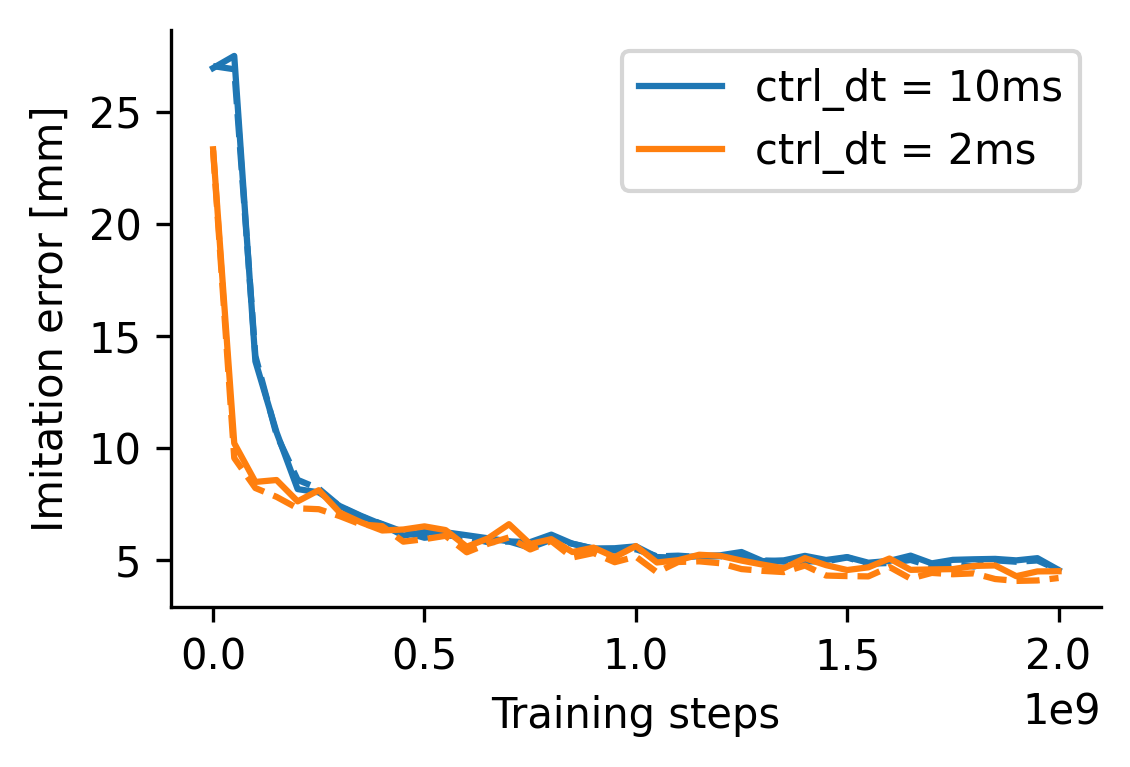

In [33]:
plt.figure(figsize=(4, 2.5), dpi=300)
for i, k in enumerate(training_results):
    x = training_results[k]["steps"]
    y_train = np.array(training_results[k]["train"]["mean_hand_L_pos_err_m"])*1000
    y_eval = np.array(training_results[k]["eval"]["mean_hand_L_pos_err_m"])*1000
    plt.plot(x, y_train, color=f"C{i}",  ls="--")
    plt.plot(x, y_eval, label=f"ctrl_dt = {ctrl_dt[k]}ms")
#plt.xticks(1e8*np.arange(6), ["0"] + [f"{i}00M" for i in range(1, 6)])
plt.legend()
plt.xlabel("Training steps")
plt.ylabel("Imitation error [mm]")
#plt.ylim(0, 12000)
#plt.xlim(0, 5e8)
sns.despine()
#plt.savefig("architecture_training_speed_comparison.svg", bbox_inches="tight")
plt.show()